In [1]:

import sys, os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.99'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import gc
import MAS_library as MASL
import pickle as pk
import skimage.measure as skmeasure
from mpi4py import MPI
from scipy.ndimage import convolve
import numpy as np
from scipy.ndimage import convolve
import jax.numpy as jnp
from jax.scipy.signal import convolve as jax_convolve

def mat_reshape_fast(mat, grid, grid_sbox):
    """Single reshape + transpose instead of multiple moveaxis"""
    grid_tot = grid * grid_sbox
    if mat.ndim == 3:
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox).transpose(0, 2, 4, 1, 3, 5)
    else:
        extra_dims = mat.shape[3:]
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox, *extra_dims).transpose(0, 2, 4, 1, 3, 5, *range(6, 6+len(extra_dims)))


def get_padded_mat_fast(Npart, n_pad, grid_sbox, grid):
    """Vectorized version using advanced indexing (no as_strided)"""
    Npart_pad = np.pad(Npart, n_pad, mode='wrap')
    box_size = grid_sbox + 2 * n_pad
    fac = box_size // grid_sbox
    
    # Build index arrays for all subboxes at once
    # Base indices for one subbox
    idx_base = np.arange(box_size)
    
    # Offsets for each grid position
    offsets = n_pad + np.arange(grid) * grid_sbox - n_pad  # shape (grid,)
    
    # Create full index arrays: shape (grid, box_size)
    idx_x = offsets[:, None] + idx_base[None, :]  # (grid, box_size)
    idx_y = offsets[:, None] + idx_base[None, :]
    idx_z = offsets[:, None] + idx_base[None, :]
    
    # Use advanced indexing with ix_ to extract all subboxes
    # Result shape: (grid, grid, grid, box_size, box_size, box_size)
    Npart_pad1 = Npart_pad[
        idx_x[:, None, None, :, None, None],
        idx_y[None, :, None, None, :, None],
        idx_z[None, None, :, None, None, :]
    ]
    
    # Block reduce using reshape + mean
    Npart_pad1_reduce = Npart_pad1.reshape(
        grid, grid, grid, grid_sbox, fac, grid_sbox, fac, grid_sbox, fac
    ).mean(axis=(4, 6, 8))
    
    return Npart_pad1_reduce, None


def process_LH_sim_fast(pos_m_truth, vel_m_truth, get_env=False, get_vel=False, 
                        get_randsel=False, grid=64, grid_sbox=8, nrand_sel_box=32768):
    norm_delta = 10
    norm_vel = 100
    BoxSize = 1000.
    MAS_type = 'CIC'
    grid_tot = grid_sbox * grid

    rho_bar = len(pos_m_truth) / (BoxSize**3)
    vol_vox = (BoxSize / grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    # Density field
    Npart = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
    MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)
    Npart /= (N_bar_vox * norm_delta)

    Npart_rs = mat_reshape_fast(Npart, grid, grid_sbox)
    
    fields_list = [Npart_rs[..., None]]
    
    if get_env or get_vel:
        Npart_cic = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
        MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)
    
    if get_env:
        # Vectorized padded fields
        Npart_pad1_rs, _ = get_padded_mat_fast(Npart, grid_sbox, grid_sbox, grid)
        Npart_pad2_rs, _ = get_padded_mat_fast(Npart, 2*grid_sbox, grid_sbox, grid)
        fields_list.extend([Npart_pad1_rs[..., None], Npart_pad2_rs[..., None]])

    if get_vel:
        # Preallocate velocity field
        vel_m_part = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
        
        # Process all 3 components
        for jc in range(3):
            mom_jc = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
            MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', 
                    verbose=False, W=vel_m_truth[:, jc].astype(np.float32))
            
            vel_m_jc = np.divide(mom_jc, Npart_cic, out=np.zeros_like(mom_jc), 
                                  where=Npart_cic != 0)
            # vel_m_jc = np.asarray(fill_empty_voxels_with_local_average(vel_m_jc))
            vel_m_part[..., jc] = vel_m_jc / norm_vel

        vel_m_part_rs = mat_reshape_fast(vel_m_part, grid, grid_sbox)
        fields_list.append(vel_m_part_rs)

    # Single concatenation at the end
    dmo_fields_all_snap = np.concatenate(fields_list, axis=-1)
    dmo_fields_all_rs = dmo_fields_all_snap.reshape((grid**3, *dmo_fields_all_snap.shape[3:]))

    # Random selection (unchanged logic, but use rng object for reproducibility)
    if (nrand_sel_box < grid**3) and get_randsel:
        rng = np.random.default_rng(0)
        Npart_sum = dmo_fields_all_rs[..., 0].sum(axis=(1, 2, 3))
        
        npart_min, npart_max = np.percentile(Npart_sum, [2.0, 98.0])
        Npart_clipped = np.clip(Npart_sum, npart_min, npart_max)
        
        hist, bins_edges = np.histogram(Npart_clipped, bins=16)
        bins_edges[0], bins_edges[-1] = 0.0, bins_edges[-1] * 100
        nsel_per_jb = nrand_sel_box // len(hist)

        indsel_all = []
        for jbd in range(len(bins_edges) - 1):
            indsel = np.where((Npart_sum >= bins_edges[jbd]) & 
                             (Npart_sum < bins_edges[jbd + 1]))[0]
            n_sel = min(len(indsel), nsel_per_jb)
            if n_sel > 0:
                indsel_all.append(rng.choice(indsel, n_sel, replace=False))

        indsel_all = np.concatenate(indsel_all)
        
        if len(indsel_all) < nrand_sel_box:
            remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
            indsel_all = np.concatenate([
                indsel_all, 
                rng.choice(remaining, nrand_sel_box - len(indsel_all), replace=False)
            ])

        rand_sel = rng.permutation(indsel_all)
        Npart_sum_sel = Npart_sum[rand_sel]
    else:
        rand_sel = np.arange(grid**3)
        Npart_sum = Npart_sum_sel = 0

    return dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel

    

In [5]:
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
# res = 512  # the particles live on a Lagrangrian grid of resolution (res)^dim
res = 512  # the particles live on a Lagrangrian grid of resolution (res)^dim

factor = 2
n_order = 2
a_ic = 1./128.
# numsteps = 20  # number of steps to be performed
# a_end = 1./1.5

z_snaps = [2.,  1., 0.5]
a_end_all = [1/(1+z_snaps[0]), 1/(1+z_snaps[1]), 1/(1+z_snaps[2])]
a_init_all = [a_ic, a_end_all[0], a_end_all[1]]

numsteps_all = [10, 5, 5]

# Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = int(factor * res)
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None

grid_sbox = 8
grid = 64
nrand_sel_box = 32768

def run_one_simulation(sim_id):
        path_ic = root + "LH/%d/ICs"%(sim_id)
        root_out = root + "rhog_LH_nsnap_3_nsel_32768/%d/"%(sim_id)
        os.makedirs(root_out, exist_ok=True)

        savefname_dmo_fields = root_out + 'dmo2_fields_subvols_grid_%d_LH_%d.npy'%(grid_sbox, sim_id)  
        meta_fname = root_out + 'meta_dmo2_fields_subvols_grid_%d_LH_%d.pkl'%(grid_sbox, sim_id)


        # check if the file exists, else print the number:
        # if not os.path.exists(savefname_dmo_fields) or not os.path.exists(meta_fname):
        if 1:
                print("File missing for sim_id: ", sim_id)


                # read Cosmo_params.dat file to get cosmological parameters:
                cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



                Om = cosmo_all[0]
                Ob = cosmo_all[1]
                h = cosmo_all[2]
                ns = cosmo_all[3]
                sigma8 = cosmo_all[4]
                Oc = Om - Ob

                # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
                ic_delta = np.load(path_ic+"/IC_delta640.npy")
                ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

                cosmo = dict(Omega_c=Oc,  # cold dark matter content
                                Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                                h=h,  # dimensionless Hubble constant
                                n_s=ns,  # scalar spectral index
                                sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                                )

                dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

                # Compute the linear power spectrum
                dj = dj.with_timetables()
                Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

                dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
                dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

                for ja in range(len(a_end_all)):
                        print("Running PM simulation for snap %d at a_end = %.3f"%(ja, a_end_all[ja]))
                        X_sim, P_sim, _ = dj.run_nbody(
                                a_ini=a_init_all[ja], a_end=a_end_all[ja], n_steps=numsteps_all[ja], res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method,
                                antialias=antialias, grad_kernel_order=grad_kernel_order,
                                laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False,
                                chunk_size=chunk_size)
                        # convert to km/s

                        dj = dj.with_external_ics(pos=X_sim.reshape(-1, 3), vel=P_sim.reshape(-1, 3))
                        P_sim = P_sim / a_end_all[ja] * 100.
                        X_sim = np.array(X_sim)
                        P_sim = np.array(P_sim)
                        X_sim = np.reshape(X_sim, (-1,3))
                        P_sim = np.reshape(P_sim, (-1,3))

                        if ja == 1:
                                get_env = True
                                get_vel = True
                                get_randsel = False
                        elif ja == 2:
                                get_env = True
                                get_vel = True
                                get_randsel = True

                        else:
                                get_env = False
                                get_vel = False
                                get_randsel = False

                        dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel = process_LH_sim_fast(X_sim, P_sim, get_env=get_env, get_vel=get_vel, get_randsel=get_randsel, grid_sbox=grid_sbox, grid=grid, nrand_sel_box=nrand_sel_box)

                        if ja == 0:
                                dmo_fields_all_rs_all = dmo_fields_all_rs
                        else:
                                dmo_fields_all_rs_all = np.concatenate((dmo_fields_all_rs_all, dmo_fields_all_rs), axis=-1)

                        if ja == len(a_end_all)-1:
                                np.save(root_out+"/pos_LH%d_z05.npy"%sim_id,X_sim)
                                np.save(root_out+"/vel_LH%d_z05.npy"%sim_id,P_sim)

                        del X_sim, P_sim, dmo_fields_all_rs
                        gc.collect()
                        jax.clear_caches()      

                        print("Done snap %d"%(ja))                      
                                

                print("Simulation %d done."%(sim_id))



                # np.save(savefname_dmo_fields, dmo_fields_all_rs_all.astype(np.float16)[rand_sel, ...])
                # # np.save(savefname_rand_indices, rand_sel)
                # saved = {
                #         'zsnaps': z_snaps,
                #         'Npart_sum_all': Npart_sum,
                #         'Npart_sum_sel': Npart_sum_sel,
                #         'norm_delta': norm_delta,
                #         'norm_vel': norm_vel,
                #         'grid_sbox':grid_sbox,
                #         'grid':grid,
                #         'rand_sel': rand_sel     
                #         }
                # pk.dump(saved, open(meta_fname, 'wb'))

                del dj, ic_delta
                gc.collect()
                jax.clear_caches()


                return
        else:
                return




In [6]:
run_one_simulation(0)




File missing for sim_id:  0


AssertionError: Density contrast has incorrect shape: (640, 640, 640), should be: (512, 512, 512)

In [ ]:
import sys, os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.99'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import gc
import MAS_library as MASL
import pickle as pk
import skimage.measure as skmeasure
from mpi4py import MPI
from scipy.ndimage import convolve

def fill_empty_voxels_with_local_average(vel_field):
    mask = (vel_field != 0.).astype(np.float32)
    kernel = np.ones((3, 3, 3), dtype=np.float32)
    vel_sum = convolve(vel_field* mask, kernel, mode='wrap')
    weight_sum = convolve(mask, kernel, mode='wrap')
    weight_sum[weight_sum == 0] = 1.0
    vel_avg = vel_sum / weight_sum
    vel_filled= np.where(mask > 0, vel_field, vel_avg)
    
    return vel_filled

def mat_reshape(mat, grid1, grid2):
    '''
    Reshape input mat into (grid1, grid1, grid1, grid2, grid2, grid2) shape
    '''
    if len(mat.shape) == 3:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2))
    else:
        mat_rs = np.reshape(mat, (grid1, grid2, grid1, grid2, grid1, grid2, *mat.shape[3:]))

    mat_rs = np.moveaxis(mat_rs, 1, 2)
    mat_rs = np.moveaxis(mat_rs, 4, 3)
    mat_rs = np.moveaxis(mat_rs, 3, 2)
    return mat_rs

def get_padded_mat(Npart, n_pad, grid_sbox, grid):
    Npart_pad = np.pad(Npart, n_pad, 'wrap')

    Npart_pad1 = np.zeros((grid, grid, grid, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad, grid_sbox + 2*n_pad))
    fac = (grid_sbox + 2*n_pad)//grid_sbox    
    Npart_pad1_reduce = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox))    
    xstart, ystart, zstart = n_pad, n_pad, n_pad
    for jx in range(grid):
        for jy in range(grid):
            for jz in range(grid):
                Npart_pad1[jx, jy, jz] = Npart_pad[xstart + jx * grid_sbox - n_pad:xstart + (jx + 1) * grid_sbox + n_pad,
                                                        ystart + jy * grid_sbox - n_pad:ystart + (jy + 1) * grid_sbox + n_pad,
                                                        zstart + jz * grid_sbox - n_pad:zstart + (jz + 1) * grid_sbox + n_pad]

                Npart_pad1_reduce[jx, jy, jz] = skmeasure.block_reduce(Npart_pad1[jx, jy, jz], (fac, fac, fac), np.mean)
    return Npart_pad1_reduce, Npart_pad1


def process_LH_sim(pos_m_truth,vel_m_truth, get_env=False, get_vel=False, get_randsel=False, grid = 64,grid_sbox = 8, nrand_sel_box = 32768):

        norm_delta = 10
        norm_vel = 100
        BoxSize = 1000.

        MAS_type = 'CIC'
        grid_tot = grid_sbox * grid

        import numpy as np
        np.random.seed(0)

        rho_bar = len(pos_m_truth)/(BoxSize**3)
        vol_vox = (BoxSize/grid_tot)**3
        N_bar_vox = rho_bar * vol_vox

        Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

        Npart /= N_bar_vox
        Npart /= norm_delta

        Npart_rs = mat_reshape(Npart, grid, grid_sbox)
        dmo_fields_all_snap = Npart_rs[...,None] # (gird,gird,gird, 8, 8, 8, 1)
        if get_env:

                npad1 = grid_sbox
                Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

                npad2 = 2*grid_sbox
                Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

                vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

                Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
                MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)

                dmo_fields_all_snap = np.concatenate((dmo_fields_all_snap, Npart_pad1_rs[...,None], Npart_pad2_rs[...,None]), axis=-1) # (gird,gird,gird, 8, 8, 8, 6)

        if get_vel:
                for jc in range(3):
                        mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
                        MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
                        vel_m_jc = mom_jc/Npart_cic
                        vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
                        vel_m_jc = fill_empty_voxels_with_local_average(vel_m_jc)            
                        vel_m_part[..., jc] = vel_m_jc/norm_vel

                vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

                dmo_fields_all_snap = np.concatenate((dmo_fields_all_snap, vel_m_part_rs), axis=-1) # (gird,gird,gird, 8, 8, 8, 6)




        dmo_fields_all_rs = dmo_fields_all_snap.reshape((grid**3, *dmo_fields_all_snap.shape[3:])) # (grid**3, 8, 8, 8, 6)

        if (nrand_sel_box < grid**3) and get_randsel:
                import numpy as np
                np.random.seed(0)
                # import numpy as np
                # rng = np.random.default_rng(12345)
                dmo_fields_all_rs_z0 = dmo_fields_all_rs[:, ..., 0]
                Npart_sum = np.sum(dmo_fields_all_rs_z0, axis=(1, 2, 3))

                npart_min = np.percentile(Npart_sum, 2.0)
                npart_max = np.percentile(Npart_sum, 98.0)
                
                hist, bins_edges = np.histogram(np.clip(Npart_sum, npart_min, npart_max) , bins=16)
                bins_edges[0] = 0.0
                bins_edges[-1] = bins_edges[-1]*100
                nsel_per_jb = nrand_sel_box//len(hist)

                indsel_all = []
                for jbd in range(len(bins_edges)-1):
                        b1 = bins_edges[jbd]
                        b2 = bins_edges[jbd + 1]
                        indsel = np.where((Npart_sum >= b1) & (Npart_sum < b2))[0]
                        if len(indsel) < nsel_per_jb:
                                ind_in_jb = indsel
                        else:
                        # ind_in_jb = rng.choice(indsel, nsel_per_jb, replace=False)
                                ind_in_jb = np.random.choice(indsel, nsel_per_jb, replace=False)
                                indsel_all.append(ind_in_jb)

                indsel_all = np.concatenate(indsel_all)

                if len(indsel_all) < nrand_sel_box:
                        nmore_to_sel = nrand_sel_box - len(indsel_all)
                        ind_to_sel_remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
                        # indsel_remaining = rng.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
                        indsel_remaining = np.random.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
                        indsel_all = np.concatenate((indsel_all, indsel_remaining))

                Npart_sum_sel = Npart_sum[indsel_all]
                # rand_sel = rng.permutation(indsel_all)
                rand_sel = np.random.permutation(indsel_all)
        else:
                import numpy as np
                rand_sel = np.arange(grid**3)
                Npart_sum = 0
                Npart_sum_sel = 0
                
        return dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel



devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
# res = 512  # the particles live on a Lagrangrian grid of resolution (res)^dim
res = 640  # the particles live on a Lagrangrian grid of resolution (res)^dim

factor = 1.725
n_order = 2
a_ic = 1./128.
# numsteps = 20  # number of steps to be performed
# a_end = 1./1.5

z_snaps = [2.,  1., 0.5]
a_end_all = [1/(1+z_snaps[0]), 1/(1+z_snaps[1]), 1/(1+z_snaps[2])]
a_init_all = [a_ic, a_end_all[0], a_end_all[1]]

numsteps_all = [10, 5, 5]

# Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = int(factor * res)
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None

grid_sbox = 8
grid = 64
nrand_sel_box = 32768

def run_one_simulation(sim_id):
        path_ic = root + "LH/%d/ICs"%(sim_id)
        root_out = root + "rhog_LH_nsnap_3_nsel_32768/%d/"%(sim_id)
        os.makedirs(root_out, exist_ok=True)

        # path_sim_pos = path_pm+"/pos_LH%d_z05.npy"%sim_id
        # path_sim_vel = path_pm+"/vel_LH%d_z05.npy"%sim_id

        savefname_dmo_fields = root_out + 'dmo_fields_subvols_grid_%d_LH_%d.npy'%(grid_sbox, sim_id)  
        meta_fname = root_out + 'meta_dmo_fields_subvols_grid_%d_LH_%d.pkl'%(grid_sbox, sim_id)


        # check if the file exists, else print the number:
        if not os.path.exists(savefname_dmo_fields) or not os.path.exists(meta_fname):
                print("File missing for sim_id: ", sim_id)


                # read Cosmo_params.dat file to get cosmological parameters:
                cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



                Om = cosmo_all[0]
                Ob = cosmo_all[1]
                h = cosmo_all[2]
                ns = cosmo_all[3]
                sigma8 = cosmo_all[4]
                Oc = Om - Ob

                # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
                ic_delta = np.load(path_ic+"/IC_delta640.npy")
                ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

                cosmo = dict(Omega_c=Oc,  # cold dark matter content
                                Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                                h=h,  # dimensionless Hubble constant
                                n_s=ns,  # scalar spectral index
                                sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                                )

                dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

                # Compute the linear power spectrum
                dj = dj.with_timetables()
                Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

                dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
                dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

                for ja in range(len(a_end_all)):
                        print("Running PM simulation for snap %d at a_end = %.3f"%(ja, a_end_all[ja]))
                        X_sim, P_sim, _ = dj.run_nbody(
                                a_ini=a_init_all[ja], a_end=a_end_all[ja], n_steps=numsteps_all[ja], res_pm=res_pm,
                                time_var=time_var, stepper=stepper, method=method,
                                antialias=antialias, grad_kernel_order=grad_kernel_order,
                                laplace_kernel_order=laplace_kernel_order,
                                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                                deconvolve=deconvolve, return_displacement=False,
                                chunk_size=chunk_size)
                        # convert to km/s

                        dj = dj.with_external_ics(pos=X_sim.reshape(-1, 3), vel=P_sim.reshape(-1, 3))
                        P_sim = P_sim / a_end_all[ja] * 100.
                        X_sim = np.array(X_sim)
                        P_sim = np.array(P_sim)
                        X_sim = np.reshape(X_sim, (-1,3))
                        P_sim = np.reshape(P_sim, (-1,3))

                        if ja > 0:
                                get_env = True
                                get_vel = True
                                get_randsel = True
                        else:
                                get_env = False
                                get_vel = False
                                get_randsel = False

                        dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel = process_LH_sim(X_sim, P_sim, get_env=get_env, get_vel=get_vel, get_randsel=get_randsel, grid_sbox=grid_sbox, grid=grid, nrand_sel_box=nrand_sel_box)

                        if ja == 0:
                                dmo_fields_all_rs_all = dmo_fields_all_rs
                        else:
                                dmo_fields_all_rs_all = np.concatenate((dmo_fields_all_rs_all, dmo_fields_all_rs), axis=-1)


                        del X_sim, P_sim, dmo_fields_all_rs
                        gc.collect()
                        jax.clear_caches()      

                        print("Done snap %d"%(ja))                      
                                

                print("Simulation %d done."%(sim_id))



                np.save(savefname_dmo_fields, dmo_fields_all_rs_all.astype(np.float16)[rand_sel, ...])
                # np.save(savefname_rand_indices, rand_sel)
                saved = {
                        'zsnaps': z_snaps,
                        'Npart_sum_all': Npart_sum,
                        'Npart_sum_sel': Npart_sum_sel,
                        'norm_delta': norm_delta,
                        'norm_vel': norm_vel,
                        'grid_sbox':grid_sbox,
                        'grid':grid,
                        'rand_sel': rand_sel     
                        }
                pk.dump(saved, open(meta_fname, 'wb'))

                del dj, ic_delta
                gc.collect()
                jax.clear_caches()


                return
        else:
                return


                

In [56]:
run_one_simulation(0)




File missing for sim_id:  0
Running PM simulation for snap 0 at a_end = 0.333
Done snap 0
Running PM simulation for snap 1 at a_end = 0.500


/tmp/ipykernel_1771213/1092979.py:110: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic


Done snap 1
Running PM simulation for snap 2 at a_end = 0.667
Done snap 2
Simulation 0 done.


In [ ]:
df_dm = np.load('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsnap_3_nsel_32768/0/dmo_fields_subvols_grid_8_LH_0.npy')
# df_dm.shape
metaf_new = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsnap_3_nsel_32768/0/meta_dmo_fields_subvols_grid_8_LH_0.pkl', 'rb'))
Npart_sum_all = metaf_new['Npart_sum_all']
Npart_sum_sel = metaf_new['Npart_sum_sel']

metaf_orig = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/0/meta_dmo_fields_subvols_grid_8_LH_0.pkl', 'rb'))
Npart_sum_all_orig = metaf_orig['Npart_sum_all']
Npart_sum_sel_orig = metaf_orig['Npart_sum_sel']

import matplotlib.pyplot as plt
plt.figure()
_ = plt.hist(Npart_sum_all, bins=50, alpha=0.5, label='All boxes')
_ = plt.hist(Npart_sum_sel, bins=50, alpha=0.5, label='Selected boxes')
plt.yscale('log')
plt.xscale('log')


plt.figure()
plt.imshow(np.sum(df_dm[15, :, :, :, 9], axis=0), origin='lower')
plt.colorbar()


(32768, 8, 8, 8, 13)

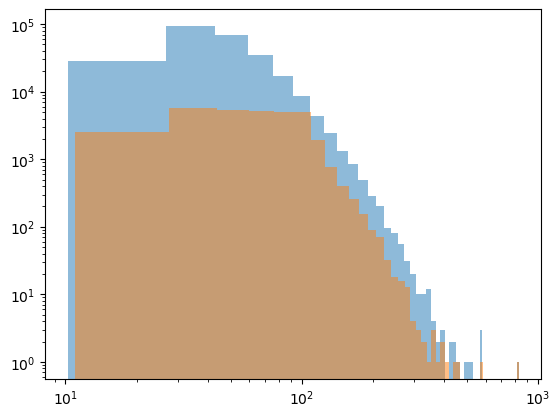

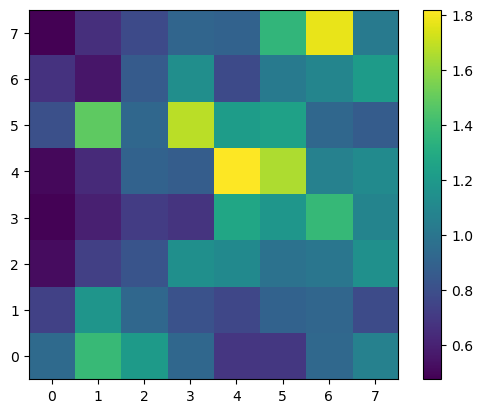

In [18]:
plt.figure()
plt.imshow(np.sum(df_dm[15, :, :, :, 9], axis=0), origin='lower')
plt.colorbar()

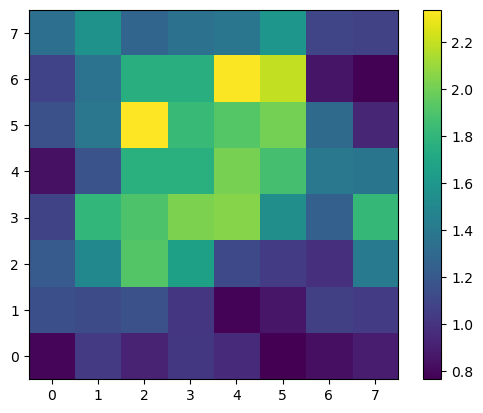

In [38]:
plt.figure()
plt.imshow(np.sum(df_dm[15, :, :, :, 0], axis=0), origin='lower')
plt.colorbar()




In [ ]:
import numpy as np
import MAS_library as MASL

# density field parameters
grid    = 512    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress

dfp = np.load('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsnap_3_nsel_32768/0/pos_LH0_z05.npy')

delta_dj = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(dfp.astype(np.float32), delta_dj, BoxSize, MAS, verbose=verbose)

import numpy as np
import readgadget

# input files
snapshot = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/0/snapdir_003/snap_003'
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read positions, velocities and IDs of the particles
posq = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h

delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(posq, delta_q, BoxSize, MAS, verbose=verbose)


delta_dj /= np.mean(delta_dj, dtype=np.float32);  delta_dj -= 1.0

delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0


import Pk_library as PKL

Pk = PKL.XPk([delta_dj,delta_q], BoxSize, 0, MAS=['CIC','CIC'], threads=1)




import matplotlib.pyplot as plt
plt.figure()
plt.plot(Pk.k3D, Pk.XPk[:,0,0]/np.sqrt(Pk.Pk[:,0,0] * Pk.Pk[:,0,1]), label='Disco-DJ')
plt.xscale('log')
plt.grid()

plt.figure()
plt.plot(Pk.k3D, Pk.Pk[:,0,0] / Pk.Pk[:,0,1], label='Disco-DJ')
plt.xscale('log')
plt.grid()






Using CIC mass assignment scheme
Time taken = 4.321 seconds




Using CIC mass assignment scheme
Time taken = 16.790 seconds




Computing power spectra of the fields...
Time FFTS = 3.63
Time loop = 2.54
Time taken = 6.18 seconds


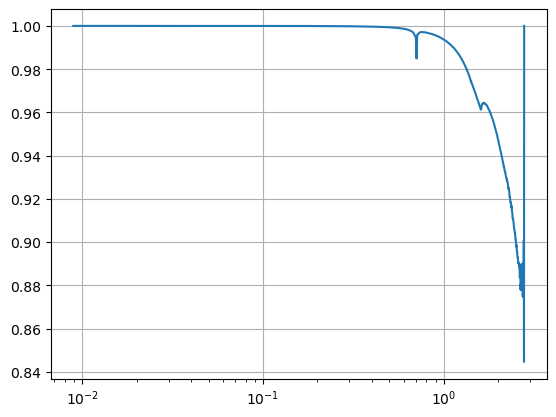

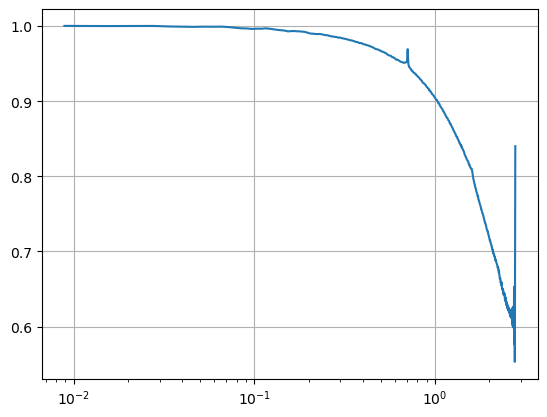

In [3]:
ldir = '/mnt/ceph/users/spandey/discodj_runs'
dforig = np.load(f'{ldir}/rhog_LH_nsel_32768/0/dmo_fields_subvols_grid_8_LH_0.npy')
dfnew = np.load(f'{ldir}/rhog_LH_nsnap_3_nsel_32768/0/dmo_fields_subvols_grid_8_LH_0.npy')




In [4]:
dforig.shape, dfnew.shape


((32768, 8, 8, 8, 6), (32768, 8, 8, 8, 8))

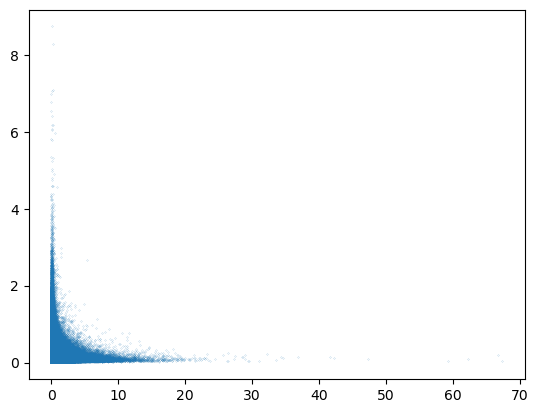

In [5]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(dforig[...,0].flatten(), dfnew[...,0].flatten(), s=0.01)




In [1]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import sys
import gc

devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
res = 640  # the particles live on a Lagrangrian grid of resolution (res)^dim
factor = 2
n_order = 2
a_ic = 1./128.
numsteps = 20  # number of steps to be performed
a_end = 1./1.5
Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = factor * res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None




ERROR:2025-12-19 16:35:38,206:jax._src.xla_bridge:475: Jax plugin configuration error: Exception when calling jax_plugins.xla_cuda12.initialize()
Traceback (most recent call last):
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax/_src/xla_bridge.py", line 473, in discover_pjrt_plugins
    plugin_module.initialize()
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 328, in initialize
    _check_cuda_versions(raise_on_first_error=True)
  File "/mnt/home/spandey/ceph/env/discodj/lib/python3.11/site-packages/jax_plugins/xla_cuda12/__init__.py", line 285, in _check_cuda_versions
    local_device_count = cuda_versions.cuda_device_count()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: jaxlib/cuda/versions_helpers.cc:113: operation cuInit(0) failed: CUDA_ERROR_NO_DEVICE


In [ ]:
def run_one_simulation(sim_id):
        path_ic = root + "%d/ICs"%(sim_id)
        path_pm = root + "%d/pm"%(sim_id)
        os.makedirs(path_pm, exist_ok=True)

        # read Cosmo_params.dat file to get cosmological parameters:
        cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



        Om = cosmo_all[0]
        Ob = cosmo_all[1]
        h = cosmo_all[2]
        ns = cosmo_all[3]
        sigma8 = cosmo_all[4]
        Oc = Om - Ob

        # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
        ic_delta = np.load(path_ic+"/IC_delta640.npy")
        ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

        cosmo = dict(Omega_c=Oc,  # cold dark matter content
                        Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                        h=h,  # dimensionless Hubble constant
                        n_s=ns,  # scalar spectral index
                        sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                        )

        dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

        # Compute the linear power spectrum
        dj = dj.with_timetables()
        Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

        dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
        dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

        X_sim, P_sim, _ = dj.run_nbody(
                a_ini=a_ic, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                time_var=time_var, stepper=stepper, method=method,
                antialias=antialias, grad_kernel_order=grad_kernel_order,
                laplace_kernel_order=laplace_kernel_order,
                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                deconvolve=deconvolve, return_displacement=False,
                chunk_size=chunk_size)
        # convert to km/s
        P_sim = P_sim / a_end * 100.
        X_sim = np.array(X_sim, dtype=np.float16)
        P_sim = np.array(P_sim, dtype=np.float16)
        X_sim = np.reshape(X_sim, (-1,3))
        P_sim = np.reshape(P_sim, (-1,3))

        print("Saving to %s"%(path_pm))
        # np.savez_compressed(path_pm + "/sim_LH%d_z05.npz" % (sim_id), pos=X_sim, vel=P_sim)
        np.save(path_pm+"/pos_LH%d_z05.npy"%sim_id,X_sim)
        np.save(path_pm+"/vel_LH%d_z05.npy"%sim_id,P_sim)

        print("Simulation %d done."%(sim_id))


        del dj, ic_delta, X_sim, P_sim
        gc.collect()
        jax.clear_caches()
        return



In [5]:
run_one_simulation(0)

# for i in range(1):
#     run_one_simulation(i)






Saving to /mnt/ceph/users/spandey/discodj_runs/LH/0/pm
Simulation 0 done.


In [ ]:
sdir = '/mnt/ceph/users/spandey/discodj_runs/LH/0/pm'
dfp = np.load(f'{sdir}/pos_LH0_z05.npy')



In [20]:
import MAS_library as MASL

def save_cic_densities(ji):
    # try:
    root_in = '/mnt/ceph/users/spandey/discodj_runs/LH/%d/pm' % ji
    root_out = '/mnt/ceph/users/spandey/discodj_runs/rhog_LH/%d/' % ji
    os.makedirs(root_out, exist_ok=True)
    grid         = 512
    BoxSize = 1000.0 #Mpc/h ; size of box
    BoxSize = 1000.0    
    pos = np.load(root_in + '/pos_LH%d_z05.npy' % ji)
    pvel = np.load(root_in + '/vel_LH%d_z05.npy' % ji)                           
    
    # pos = np.array(df['Position'], dtype=np.float64)
    rho_m_orig = np.zeros((grid,grid,grid), dtype=np.float32)
    MASL.MA(np.float32(pos), rho_m_orig, BoxSize, 'CIC', verbose=False)
    

    mom_m_x_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_x_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,0].astype(np.float32))
    mom_m_y_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_y_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,1].astype(np.float32))
    mom_m_z_orig = np.zeros((grid,grid,grid), dtype=np.float32)                
    MASL.MA(np.float32(pos), mom_m_z_orig, BoxSize, 'CIC', verbose=False, W=pvel[:,2].astype(np.float32))                

    vel_m_x_orig = mom_m_x_orig/rho_m_orig
    vel_m_y_orig = mom_m_y_orig/rho_m_orig
    vel_m_z_orig = mom_m_z_orig/rho_m_orig

    # at voxels with non-finite values, set velocities to zero:
    vel_m_x_orig[~np.isfinite(vel_m_x_orig)] = 0.0
    vel_m_y_orig[~np.isfinite(vel_m_y_orig)] = 0.0
    vel_m_z_orig[~np.isfinite(vel_m_z_orig)] = 0.0

    # divide out by 1000.:
    vel_m_x_orig /= 100.
    vel_m_y_orig /= 100.
    vel_m_z_orig /= 100.

    vel_m_all_orig = np.stack((vel_m_x_orig, vel_m_y_orig, vel_m_z_orig), axis=0).astype(np.float16)
    rho_m_orig = (rho_m_orig / 100.).astype(np.float16)
    print(np.amin(vel_m_all_orig), np.amax(vel_m_all_orig))
    print(np.amax(rho_m_orig), np.min(rho_m_orig))
    np.save(root_out+"/rho_grid_%d_LH%d_z05.npy"%(grid, ji), rho_m_orig)
    np.save(root_out+"/vel_grid_%d_LH%d_z05.npy"%(grid, ji), vel_m_all_orig)
    return


In [21]:
save_cic_densities(1)




/tmp/ipykernel_483027/1508781113.py:26: RuntimeWarning: invalid value encountered in divide
  vel_m_x_orig = mom_m_x_orig/rho_m_orig
/tmp/ipykernel_483027/1508781113.py:27: RuntimeWarning: invalid value encountered in divide
  vel_m_y_orig = mom_m_y_orig/rho_m_orig
/tmp/ipykernel_483027/1508781113.py:28: RuntimeWarning: invalid value encountered in divide
  vel_m_z_orig = mom_m_z_orig/rho_m_orig


-20.02 22.62
14.94 0.0


In [ ]:
import numpy as np
import MAS_library as MASL

# density field parameters
grid    = 256    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress

delta_dj = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(dfp.astype(np.float32), delta_dj, BoxSize, MAS, verbose=verbose)


# at this point, delta contains the effective number of particles in each voxel
# now compute overdensity and density constrast
# delta_dj /= np.mean(delta_dj, dtype=np.float32);  delta_dj -= 1.0



Using CIC mass assignment scheme
Time taken = 3.832 seconds



In [ ]:
import numpy as np
import readgadget

# input files
snapshot = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/0/snapdir_003/snap_003'
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read positions, velocities and IDs of the particles
posq = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h

delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(posq, delta_q, BoxSize, MAS, verbose=verbose)




Using CIC mass assignment scheme
Time taken = 15.568 seconds



In [11]:
delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0



In [22]:
import Pk_library as PKL

Pk = PKL.XPk([delta_dj,delta_q], BoxSize, 0, MAS=['CIC','CIC'], threads=1)




Computing power spectra of the fields...
Time FFTS = 0.39
Time loop = 0.31
Time taken = 0.70 seconds


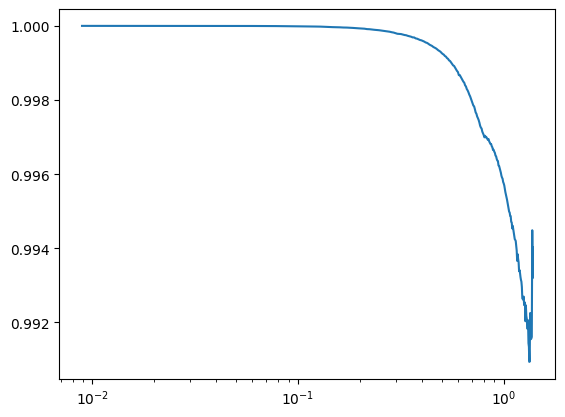

In [ ]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(Pk.k3D, Pk.XPk[:,0,0]/np.sqrt(Pk.Pk[:,0,0] * Pk.Pk[:,0,1]), label='Disco-DJ')
plt.xscale('log')

plt.figure()
plt.plot(Pk.k3D, Pk.Pk[:,0,0] / Pk.Pk[:,0,1], label='Disco-DJ')
plt.xscale('log')


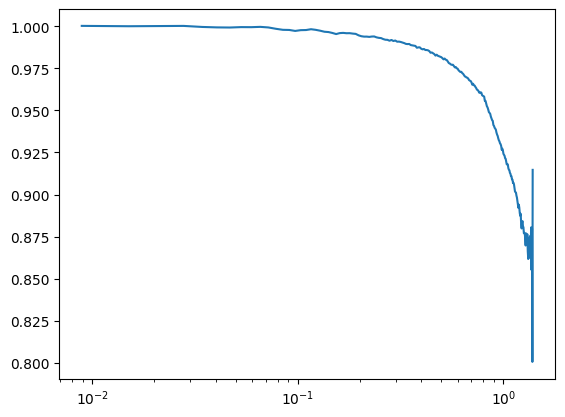

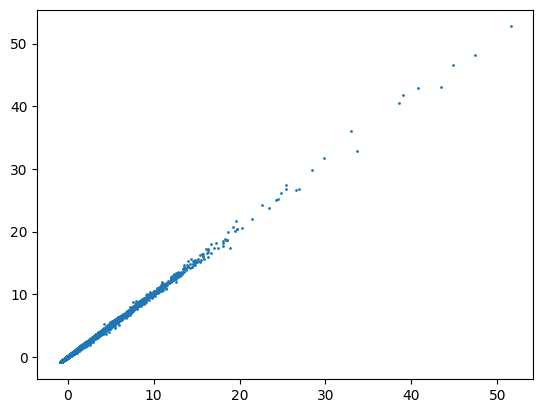

In [25]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(delta_dj.flatten()[::100], delta_q.flatten()[::100], s=1)



In [7]:
import numpy as np
import os, sys
from tqdm import tqdm

js_min = 0
js_max = 2000
js_all = np.arange(js_min, js_max).astype(int)

sdir_base = '/mnt/ceph/users/spandey/discodj_runs/LH'

for js in tqdm(js_all):

    # check if the directory exists, else create it:
    sdir = sdir_base + '/%d/'%js
    sdir_IC = sdir_base + '/%d/ICs'%js
    os.makedirs(sdir, exist_ok=True)
    os.makedirs(sdir_IC, exist_ok=True)

    ldir = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/' + str(js)
    # Pkmm_z0_file_orig = ldir + '/ICs/Pk_mm_z=0.000.txt'
    # os.system('cp %s %s'%(Pkmm_z0_file_orig, sdir_IC + '/Pk_mm_z=0.000.txt'))

    # cosmo_params_orig = ldir + '/Cosmo_params.dat'
    # os.system('cp %s %s'%(cosmo_params_orig, sdir_IC + '/Cosmo_params.dat'))

    ffile_orig = open(ldir + '/ICs/2LPT.param', 'r')
    f = ffile_orig.readlines()
    ffile_orig.close()

    variables_all = ['Seed', 'Omega ', 'OmegaLambda ', 'OmegaBaryon ', 'OmegaDM_2ndSpecies ', 'HubbleParam ', 'Redshift', 'Sigma8']
    values_all = {}
    g = ''   
    for variable in variables_all:
        for line in f:        
            if variable in line:
                # print(line.split())
                if variable == 'Seed':
                    value = int(line.split()[1])
                else:
                    value = float(line.split()[1])
                values_all[variable] = value

    ffile = open('/mnt/ceph/users/spandey/quijote_v2_gotham/GOTHAM/ICs/2LPT_base_512.param', 'r')
    f = ffile.readlines()
    ffile.close()

    g = ''   
    for line in f:
        for variable in variables_all:
            if variable in line:
                # print(line.split())
                value = values_all[variable]
                line = line.replace(line.split()[1], str(value))
                # print(line)

        g += line
            
    ffile = open(sdir_IC + '/2LPT_512.param', 'w')
    ffile.write(g)
    ffile.close()



  0%|          | 0/2000 [00:00<?, ?it/s]

100%|██████████| 2000/2000 [02:22<00:00, 14.03it/s]


In [30]:
import numpy as np
import os
from tqdm import tqdm

points = 2000

# numbers = np.where(np.arange(points)%nprocs==myrank)[0]
numbers = np.arange(points)

for sim_id in tqdm(numbers):
    #nfiles = 8
    nfiles = 64
    path = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/'
    savefname = path+'IC_delta640.npy'

    # check if the file already exists
    if os.path.exists(savefname):
        continue

    try:
        #path = f'/work/hdd/bdne/yzhang116/ICsSAM/cLH{sim_id:d}/ICs/'
        #path = f'/work/hdd/bdne/yzhang116/CV/CV_{sim_id:d}/ICs/'
        
        idx = []
        amp, phase = [], []
        print("\nConvert for path: ", path)

        for i in range(nfiles):
            # read a particular coordinate file
            f_in = path + 'Coordinates_ptype_1.%d'%i
            f = open(f_in, 'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            coordinates = np.fromfile(f, dtype=np.int64, count=-1)
            kx = (coordinates//(Nmesh//2 + 1))//Nmesh
            ky = (coordinates//(Nmesh//2 + 1))%Nmesh
            kz = (coordinates%(Nmesh//2 + 1))%Nmesh
            kk = np.array([kx, ky, kz]).T
            idx.append(kk)

            f_in = path + 'Amplitudes_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            aa = np.fromfile(f, dtype=np.float32, count=-1)
            amp.append(aa)
            f_in = path + 'Phases_ptype_1.%d'%i
            f = open(f_in,'rb')
            Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
            Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
            Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
            phase.append(np.fromfile(f, dtype=np.float32, count=-1))
    except:
        pass

    idx = np.concatenate(idx)
    amp = np.concatenate(amp)
    phase = np.concatenate(phase)

    val = amp*np.exp(1j*phase)
    cmesh = val.reshape(Nmesh, Nmesh, kz.max()+1)

    bs=1000     #Mpc/h
    mesh = np.fft.irfftn(cmesh, norm='ortho') * Nmesh**1.5
    #np.save(path+'IC_delta128_cLH%d.npy'%sim_id, mesh.astype(np.float32))
    np.save(savefname, mesh.astype(np.float32))


    for i in range(nfiles):
        os.remove(path + 'Coordinates_ptype_1.%d'%i)
        os.remove(path + 'Amplitudes_ptype_1.%d'%i)
        os.remove(path + 'Phases_ptype_1.%d'%i)




  2%|▏         | 35/2000 [00:00<00:05, 345.34it/s]


Convert for path:  /mnt/ceph/users/spandey/discodj_runs/LH/68/ICs/


  3%|▎         | 69/2000 [00:58<32:20,  1.00s/it] 


Convert for path:  /mnt/ceph/users/spandey/discodj_runs/LH/78/ICs/


  4%|▍         | 78/2000 [01:07<27:45,  1.15it/s]


ValueError: cannot reshape array of size 20544000 into shape (640,640,321)

In [31]:
numbers = np.arange(10)
for sim_id in tqdm(numbers):
    #nfiles = 8
    nfiles = 128
    path = f'/mnt/ceph/users/spandey/discodj_runs/LH/{sim_id}/ICs/'
    for i in range(nfiles):
        try:
            os.remove(path + 'Coordinates_ptype_1.%d'%i)
            os.remove(path + 'Amplitudes_ptype_1.%d'%i)
            os.remove(path + 'Phases_ptype_1.%d'%i)
        except:
            pass
        

100%|██████████| 10/10 [00:08<00:00,  1.20it/s]


In [1]:
import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
# preallocate 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.95'
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import sys
import gc

devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
# device = "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"

dim = 3
precision = "single"
# Define the boxsize and resolution
boxsize = 1000.0  # in Mpc/h
res = 640  # the particles live on a Lagrangrian grid of resolution (res)^dim
factor = 2
n_order = 2
a_ic = 1./128.
numsteps = 20  # number of steps to be performed
a_end = 1./1.5
Ob = 0.049
# stepper = "bullfrog"
stepper = "fastpm"
method = "pm"
res_pm = factor * res
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None




def run_one_simulation(sim_id):
        path_ic = root + "%d/ICs"%(sim_id)
        path_pm = root + "%d/pm"%(sim_id)
        os.makedirs(path_pm, exist_ok=True)

        # read Cosmo_params.dat file to get cosmological parameters:
        cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')



        Om = cosmo_all[0]
        Ob = cosmo_all[1]
        h = cosmo_all[2]
        ns = cosmo_all[3]
        sigma8 = cosmo_all[4]
        Oc = Om - Ob

        # if not(os.path.exists(path_pm)):  os.system('mkdir %s'%path_pm)
        ic_delta = np.load(path_ic+"/IC_delta640.npy")
        ic_delta = jnp.array(ic_delta, dtype=jnp.float32)

        cosmo = dict(Omega_c=Oc,  # cold dark matter content
                        Omega_b=Ob,  # baryonic content (note: Disco-DJ so far only performs N-body simulations, no hydro; this is only used for the linear power spectrum!)
                        h=h,  # dimensionless Hubble constant
                        n_s=ns,  # scalar spectral index
                        sigma8=sigma8  # amplitude of matter density fluctuations at a scale of 8 Mpc/h
                        )

        dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)

        # Compute the linear power spectrum
        dj = dj.with_timetables()
        Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])

        dj = dj.with_external_ics(delta = ic_delta/Dplus_aic)
        dj = dj.with_lpt(n_order=n_order, try_to_jit=True)

        X_sim, P_sim, _ = dj.run_nbody(
                a_ini=a_ic, a_end=a_end, n_steps=numsteps, res_pm=res_pm,
                time_var=time_var, stepper=stepper, method=method,
                antialias=antialias, grad_kernel_order=grad_kernel_order,
                laplace_kernel_order=laplace_kernel_order,
                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                deconvolve=deconvolve, return_displacement=False,
                chunk_size=chunk_size)
        # convert to km/s
        P_sim = P_sim / a_end * 100.
        X_sim = np.array(X_sim, dtype=np.float16)
        P_sim = np.array(P_sim, dtype=np.float16)
        X_sim = np.reshape(X_sim, (-1,3))
        P_sim = np.reshape(P_sim, (-1,3))

        print("Saving to %s"%(path_pm))
        # np.savez_compressed(path_pm + "/sim_LH%d_z05.npz" % (sim_id), pos=X_sim, vel=P_sim)
        np.save(path_pm+"/pos_LH%d_z05.npy"%sim_id,X_sim)
        np.save(path_pm+"/vel_LH%d_z05.npy"%sim_id,P_sim)

        print("Simulation %d done."%(sim_id))


        del dj, ic_delta, X_sim, P_sim
        gc.collect()
        jax.clear_caches()
        return





In [2]:
# clear up jax caches
jax.clear_caches()
gc.collect()

# sim_id = int(sys.argv[1])

run_one_simulation(0)




W1218 22:29:22.724297 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:22.837564 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:22.991531 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W1218 22:29:23.320592 1244942 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 7.82GiB with freed_by_count=0. The caller indicates tha

Saving to /mnt/ceph/users/spandey/discodj_runs/LH/0/pm
Simulation 0 done.


In [11]:
from tqdm import tqdm
import sys, os
root = "/mnt/ceph/users/spandey/discodj_runs/LH/"
for sim_id in tqdm(range(2000)):
    path_pm = root + "%d/pm"%(sim_id)
    path_ic = root + "%d/ICs"%(sim_id)
    path_sim = path_pm+"/pos_LH%d_z05.npy"%sim_id
    # path_ICs = path_ic + '/IC_delta640.npy'
    # check if the file exists, else print the number:
    if not os.path.exists(path_sim):
    # if not os.path.exists(path_ICs):        
        print("File missing for sim_id: ", sim_id)




100%|██████████| 2000/2000 [00:06<00:00, 322.89it/s]


In [17]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.99'
os.environ['NUMBA_NUM_THREADS'] = '32'
print("NUMBA_NUM_THREADS set to: ", os.environ['NUMBA_NUM_THREADS'])
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
import jax.numpy as jnp
from jax._src.lib import xla_client
import gc
import MAS_library as MASL
import pickle as pk
import skimage.measure as skmeasure
from mpi4py import MPI
from scipy.ndimage import convolve
import time
from numba import njit, prange

# =============================================================================
# TIMING UTILITIES
# =============================================================================
ENABLE_TIMING = False

class Timer:
    """Simple timer using explicit start/stop calls."""
    def __init__(self, enabled=True):
        self.enabled = enabled
        self.records = {}
        self._start_times = {}
    
    def start(self, name):
        if self.enabled:
            self._start_times[name] = time.perf_counter()
    
    def stop(self, name):
        if not self.enabled:
            return
        if name not in self._start_times:
            return
        elapsed = time.perf_counter() - self._start_times[name]
        if name not in self.records:
            self.records[name] = []
        self.records[name].append(elapsed)
        print(f"[TIMER] {name}: {elapsed:.4f}s")
        del self._start_times[name]
    
    def summary(self):
        if not self.enabled or not self.records:
            return
        print("\n" + "="*60)
        print("TIMING SUMMARY")
        print("="*60)
        for name, times in sorted(self.records.items(), key=lambda x: -sum(x[1])):
            total = sum(times)
            avg = total / len(times)
            print(f"{name:40s} | total: {total:8.3f}s | calls: {len(times):3d} | avg: {avg:.4f}s")
        print("="*60 + "\n")
    
    def reset(self):
        self.records = {}
        self._start_times = {}

timer = Timer(enabled=ENABLE_TIMING)

# =============================================================================
# NUMBA-ACCELERATED FUNCTIONS
# =============================================================================

@njit(parallel=True, fastmath=True, cache=True)
def _get_padded_mat_numba_core(Npart_pad, n_pad, grid_sbox, grid, fac):
    """
    Numba-parallelized extraction and block reduction.
    Avoids creating massive intermediate arrays.
    """
    fac3_inv = np.float32(1.0 / (fac * fac * fac))
    result = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox), dtype=np.float32)
    
    # Parallelize over all grid cells
    for idx in prange(grid * grid * grid):
        gi = idx // (grid * grid)
        gj = (idx // grid) % grid
        gk = idx % grid
        
        # Starting position in padded array
        i0 = gi * grid_sbox
        j0 = gj * grid_sbox
        k0 = gk * grid_sbox
        
        for si in range(grid_sbox):
            i_base = i0 + si * fac
            for sj in range(grid_sbox):
                j_base = j0 + sj * fac
                for sk in range(grid_sbox):
                    k_base = k0 + sk * fac
                    
                    # Sum over the fac^3 block
                    total = np.float32(0.0)
                    for di in range(fac):
                        for dj in range(fac):
                            for dk in range(fac):
                                total += Npart_pad[i_base + di, j_base + dj, k_base + dk]
                    
                    result[gi, gj, gk, si, sj, sk] = total * fac3_inv
    
    return result


@njit(parallel=True, fastmath=True, cache=True)
def _velocity_field_numba(pos, vel, Npart_cic, BoxSize, grid_tot, norm_vel):
    """
    Compute velocity field with momentum weighting.
    Returns velocity field of shape (grid_tot, grid_tot, grid_tot, 3)
    """
    vel_field = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
    mom_field = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
    
    cell_size = BoxSize / grid_tot
    n_part = pos.shape[0]
    
    # CIC assignment for momentum
    for p in prange(n_part):
        # Get cell indices
        x = pos[p, 0] / cell_size
        y = pos[p, 1] / cell_size
        z = pos[p, 2] / cell_size
        
        # Integer and fractional parts
        i = int(x)
        j = int(y)
        k = int(z)
        
        dx = x - i
        dy = y - j
        dz = z - k
        
        # Wrap indices
        i0 = i % grid_tot
        j0 = j % grid_tot
        k0 = k % grid_tot
        i1 = (i + 1) % grid_tot
        j1 = (j + 1) % grid_tot
        k1 = (k + 1) % grid_tot
        
        # CIC weights
        w000 = (1 - dx) * (1 - dy) * (1 - dz)
        w001 = (1 - dx) * (1 - dy) * dz
        w010 = (1 - dx) * dy * (1 - dz)
        w011 = (1 - dx) * dy * dz
        w100 = dx * (1 - dy) * (1 - dz)
        w101 = dx * (1 - dy) * dz
        w110 = dx * dy * (1 - dz)
        w111 = dx * dy * dz
        
        for c in range(3):
            v = vel[p, c]
            mom_field[i0, j0, k0, c] += w000 * v
            mom_field[i0, j0, k1, c] += w001 * v
            mom_field[i0, j1, k0, c] += w010 * v
            mom_field[i0, j1, k1, c] += w011 * v
            mom_field[i1, j0, k0, c] += w100 * v
            mom_field[i1, j0, k1, c] += w101 * v
            mom_field[i1, j1, k0, c] += w110 * v
            mom_field[i1, j1, k1, c] += w111 * v
    
    # Divide by density to get velocity
    norm_vel_inv = np.float32(1.0 / norm_vel)
    for i in prange(grid_tot):
        for j in range(grid_tot):
            for k in range(grid_tot):
                n = Npart_cic[i, j, k]
                if n > 0:
                    for c in range(3):
                        vel_field[i, j, k, c] = mom_field[i, j, k, c] / n * norm_vel_inv
    
    return vel_field


def get_padded_mat_numba(Npart, n_pad, grid_sbox, grid):
    """Wrapper for numba-accelerated padded matrix computation."""
    timer.start("get_padded_mat:pad")
    Npart_pad = np.pad(Npart, n_pad, mode='wrap').astype(np.float32)
    timer.stop("get_padded_mat:pad")
    
    box_size = grid_sbox + 2 * n_pad
    fac = box_size // grid_sbox
    
    timer.start("get_padded_mat:numba_core")
    result = _get_padded_mat_numba_core(Npart_pad, n_pad, grid_sbox, grid, fac)
    timer.stop("get_padded_mat:numba_core")
    
    return result, None


# =============================================================================
# PROCESSING FUNCTIONS
# =============================================================================

def mat_reshape_fast(mat, grid, grid_sbox):
    """Single reshape + transpose instead of multiple moveaxis"""
    grid_tot = grid * grid_sbox
    if mat.ndim == 3:
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox).transpose(0, 2, 4, 1, 3, 5)
    else:
        extra_dims = mat.shape[3:]
        return mat.reshape(grid, grid_sbox, grid, grid_sbox, grid, grid_sbox, *extra_dims).transpose(0, 2, 4, 1, 3, 5, *range(6, 6+len(extra_dims)))


def process_LH_sim_fast(pos_m_truth, vel_m_truth, get_env=False, get_vel=False, 
                        get_randsel=False, grid=64, grid_sbox=8, nrand_sel_box=32768):
    norm_delta = 10
    norm_vel = 100
    BoxSize = 1000.
    MAS_type = 'CIC'
    grid_tot = grid_sbox * grid

    rho_bar = len(pos_m_truth) / (BoxSize**3)
    vol_vox = (BoxSize / grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    # Density field
    timer.start("process:density_MAS")
    Npart = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
    pos_copy = np.array(pos_m_truth, dtype=np.float32, copy=True)
    MASL.MA(pos_copy, Npart, BoxSize, MAS_type, verbose=False)
    # Npart /= (N_bar_vox * norm_delta)
    timer.stop("process:density_MAS")

    timer.start("process:density_reshape")
    Npart_rs = mat_reshape_fast(Npart, grid, grid_sbox)
    timer.stop("process:density_reshape")
    
    fields_list = [Npart_rs[..., None]/(N_bar_vox * norm_delta), np.log1p(Npart_rs)[..., None]]
    
    if get_env or get_vel:
        timer.start("process:cic_for_vel_env")
        Npart_cic = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
        MASL.MA(pos_copy, Npart_cic, BoxSize, 'CIC', verbose=False)
        timer.stop("process:cic_for_vel_env")
    
    if get_env:
        # Use numba-accelerated version
        timer.start("process:env_pad1")
        Npart_pad1_rs, _ = get_padded_mat_numba(Npart, grid_sbox, grid_sbox, grid)
        timer.stop("process:env_pad1")
        
        timer.start("process:env_pad2")
        Npart_pad2_rs, _ = get_padded_mat_numba(Npart, 2*grid_sbox, grid_sbox, grid)
        timer.stop("process:env_pad2")
        fields_list.extend([Npart_pad1_rs[..., None]/(N_bar_vox * norm_delta), np.log1p(Npart_pad1_rs)[..., None], Npart_pad2_rs[..., None]/(N_bar_vox * norm_delta)])

    if get_vel:
        timer.start("process:velocity_field")
        vel_m_part = np.zeros((grid_tot, grid_tot, grid_tot, 3), dtype=np.float32)
        vel_copy = np.array(vel_m_truth, dtype=np.float32, copy=True)
        
        for jc in range(3):
            mom_jc = np.zeros((grid_tot, grid_tot, grid_tot), dtype=np.float32)
            MASL.MA(pos_copy, mom_jc, BoxSize, 'CIC', verbose=False, W=vel_copy[:, jc])
            
            vel_m_jc = np.divide(mom_jc, Npart_cic, out=np.zeros_like(mom_jc), 
                                  where=Npart_cic != 0)
            vel_m_part[..., jc] = vel_m_jc / norm_vel
        timer.stop("process:velocity_field")

        timer.start("process:velocity_reshape")
        vel_m_part_rs = mat_reshape_fast(vel_m_part, grid, grid_sbox)
        timer.stop("process:velocity_reshape")
        fields_list.append(vel_m_part_rs)

    timer.start("process:concatenate")
    dmo_fields_all_snap = np.concatenate(fields_list, axis=-1)
    dmo_fields_all_rs = dmo_fields_all_snap.reshape((grid**3, *dmo_fields_all_snap.shape[3:]))
    timer.stop("process:concatenate")

    # Random selection
    if (nrand_sel_box < grid**3) and get_randsel:
        timer.start("process:random_selection")
        rng = np.random.default_rng(0)
        Npart_sum = dmo_fields_all_rs[..., 0].sum(axis=(1, 2, 3))
        
        npart_min, npart_max = np.percentile(Npart_sum, [2.0, 98.0])
        Npart_clipped = np.clip(Npart_sum, npart_min, npart_max)
        
        hist, bins_edges = np.histogram(Npart_clipped, bins=16)
        bins_edges[0], bins_edges[-1] = 0.0, bins_edges[-1] * 100
        nsel_per_jb = nrand_sel_box // len(hist)

        indsel_all = []
        for jbd in range(len(bins_edges) - 1):
            indsel = np.where((Npart_sum >= bins_edges[jbd]) & 
                             (Npart_sum < bins_edges[jbd + 1]))[0]
            n_sel = min(len(indsel), nsel_per_jb)
            if n_sel > 0:
                indsel_all.append(rng.choice(indsel, n_sel, replace=False))

        indsel_all = np.concatenate(indsel_all)
        
        if len(indsel_all) < nrand_sel_box:
            remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
            indsel_all = np.concatenate([
                indsel_all, 
                rng.choice(remaining, nrand_sel_box - len(indsel_all), replace=False)
            ])

        rand_sel = rng.permutation(indsel_all)
        Npart_sum_sel = Npart_sum[rand_sel]
        timer.stop("process:random_selection")
    else:
        rand_sel = np.arange(grid**3)
        Npart_sum = Npart_sum_sel = 0

    # any non-finite values set to zero:
    dmo_fields_all_rs[~np.isfinite(dmo_fields_all_rs)] = 0.0

    return dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel


# =============================================================================
# CONFIGURATION
# =============================================================================
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
root = "/mnt/ceph/users/spandey/discodj_runs/"

dim = 3
precision = "single"
boxsize = 1000.0
res = 512
factor = 2
n_order = 2
a_ic = 1./128.

z_snaps = [2., 1., 0.5]
a_end_all = [1/(1+z_snaps[0]), 1/(1+z_snaps[1]), 1/(1+z_snaps[2])]
a_init_all = [a_ic, a_end_all[0], a_end_all[1]]
numsteps_all = [10, 5, 5]

stepper = "fastpm"
method = "pm"
res_pm = int(factor * res)
time_var = "D"
antialias = 0
grad_kernel_order = 4
laplace_kernel_order = 0
worder = 2
n_resample = 1
deconvolve = False
nlpt_order_ics = n_order
chunk_size = None

grid_sbox = 8
grid = 64
nrand_sel_box = 32768


# =============================================================================
# WARMUP NUMBA (compile before timing)
# =============================================================================
def warmup_numba():
    """Pre-compile numba functions to avoid JIT overhead in timing."""
    print("Warming up numba functions...")
    dummy = np.random.randn(64, 64, 64).astype(np.float32)
    dummy_pad = np.pad(dummy, 4, mode='wrap').astype(np.float32)
    _ = _get_padded_mat_numba_core(dummy_pad, 4, 8, 8, 3)
    print("Numba warmup complete.")


# =============================================================================
# MAIN SIMULATION FUNCTION
# =============================================================================
def run_one_simulation(sim_id):
    path_ic = root + "LH/%d/ICs" % (sim_id)
    root_out = root + "rhog_LH_np_512_nsnap_3_nsel_32768/%d/" % (sim_id)
    os.makedirs(root_out, exist_ok=True)

    savefname_dmo_fields = root_out + 'dmo_fields_subvols_grid_%d_LH_%d.npy' % (grid_sbox, sim_id)
    meta_fname = root_out + 'meta_dmo_fields_subvols_grid_%d_LH_%d.pkl' % (grid_sbox, sim_id)

    if not os.path.exists(savefname_dmo_fields) or not os.path.exists(meta_fname):
        print("File missing for sim_id: ", sim_id)

        timer.start("load_cosmo_params")
        cosmo_all = np.loadtxt(path_ic + "/Cosmo_params.dat", delimiter=' ')
        Om = cosmo_all[0]
        Ob = cosmo_all[1]
        h = cosmo_all[2]
        ns = cosmo_all[3]
        sigma8 = cosmo_all[4]
        Oc = Om - Ob
        timer.stop("load_cosmo_params")

        timer.start("load_ic_delta")
        # ic_delta = np.load(path_ic + "/IC_delta640.npy")
        ic_delta = np.load(path_ic + "/IC_delta512.npy")

        ic_delta = jnp.array(ic_delta, dtype=jnp.float32)
        timer.stop("load_ic_delta")

        cosmo = dict(
            Omega_c=Oc,
            Omega_b=Ob,
            h=h,
            n_s=ns,
            sigma8=sigma8
        )

        timer.start("init_discodj")
        dj = DiscoDJ(dim=dim, res=res, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
        dj = dj.with_timetables()
        Dplus_aic = np.interp(jnp.log10(a_ic), jnp.log10(dj.cosmo._timetables['a']), dj.cosmo._timetables['Dplus'])
        dj = dj.with_external_ics(delta=ic_delta / Dplus_aic)
        dj = dj.with_lpt(n_order=n_order, try_to_jit=True)
        timer.stop("init_discodj")

        for ja in range(len(a_end_all)):
            print("Running PM simulation for snap %d at a_end = %.3f" % (ja, a_end_all[ja]))
            
            timer.start(f"nbody_snap_{ja}")
            X_sim, P_sim, _ = dj.run_nbody(
                a_ini=a_init_all[ja], a_end=a_end_all[ja], n_steps=numsteps_all[ja], res_pm=res_pm,
                time_var=time_var, stepper=stepper, method=method,
                antialias=antialias, grad_kernel_order=grad_kernel_order,
                laplace_kernel_order=laplace_kernel_order,
                nlpt_order_ics=nlpt_order_ics, n_resample=n_resample,
                deconvolve=deconvolve, return_displacement=False,
                chunk_size=chunk_size)
            timer.stop(f"nbody_snap_{ja}")

            timer.start(f"post_nbody_convert_snap_{ja}")
            dj = dj.with_external_ics(pos=X_sim.reshape(-1, 3), vel=P_sim.reshape(-1, 3))
            P_sim = P_sim / a_end_all[ja] * 100.
            X_sim = np.asarray(X_sim).reshape(-1, 3)
            P_sim = np.asarray(P_sim).reshape(-1, 3)
            timer.stop(f"post_nbody_convert_snap_{ja}")

            if ja == 1:
                get_env, get_vel, get_randsel = True, True, False
            elif ja == 2:
                get_env, get_vel, get_randsel = True, True, True
            else:
                get_env, get_vel, get_randsel = False, False, False

            timer.start(f"process_sim_snap_{ja}")
            dmo_fields_all_rs, rand_sel, Npart_sum, Npart_sum_sel, norm_delta, norm_vel = process_LH_sim_fast(
                X_sim, P_sim, get_env=get_env, get_vel=get_vel, get_randsel=get_randsel,
                grid_sbox=grid_sbox, grid=grid, nrand_sel_box=nrand_sel_box
            )
            timer.stop(f"process_sim_snap_{ja}")

            if ja == 0:
                dmo_fields_all_rs_all = dmo_fields_all_rs
            else:
                timer.start(f"concat_snap_{ja}")
                dmo_fields_all_rs_all = np.concatenate((dmo_fields_all_rs_all, dmo_fields_all_rs), axis=-1)
                timer.stop(f"concat_snap_{ja}")

            # if ja == 2:
            #     np.save(root_out+"/pos_LH%d_z05.npy"%sim_id,X_sim)
            #     np.save(root_out+"/vel_LH%d_z05.npy"%sim_id,P_sim)

            del X_sim, P_sim, dmo_fields_all_rs
            gc.collect()
            jax.clear_caches()

            print("Done snap %d" % (ja))

        print("Simulation %d done." % (sim_id))

        timer.start("save_outputs")
        np.save(savefname_dmo_fields, dmo_fields_all_rs_all.astype(np.float16)[rand_sel, ...])
        saved = {
            'cosmo':cosmo,
            'zsnaps': z_snaps,
            'Npart_sum_all': Npart_sum,
            'Npart_sum_sel': Npart_sum_sel,
            'norm_delta': norm_delta,
            'norm_vel': norm_vel,
            'grid_sbox': grid_sbox,
            'grid': grid,
            'rand_sel': rand_sel
        }
        pk.dump(saved, open(meta_fname, 'wb'))
        timer.stop("save_outputs")

        del dj, ic_delta
        gc.collect()
        jax.clear_caches()

        timer.summary()
        return
    else:
        return


NUMBA_NUM_THREADS set to:  32


In [18]:

# =============================================================================
# ENTRY POINT
# =============================================================================
# if __name__ == "__main__":
jax.clear_caches()
gc.collect()

sim_id = 0
run_one_simulation(sim_id)




File missing for sim_id:  0
Running PM simulation for snap 0 at a_end = 0.333
Done snap 0
Running PM simulation for snap 1 at a_end = 0.500
Done snap 1
Running PM simulation for snap 2 at a_end = 0.667
Done snap 2
Simulation 0 done.



Using CIC mass assignment scheme
Time taken = 2.478 seconds


Using CIC mass assignment scheme
Time taken = 17.714 seconds


Computing power spectra of the fields...
Time FFTS = 3.71
Time loop = 2.68
Time taken = 6.40 seconds


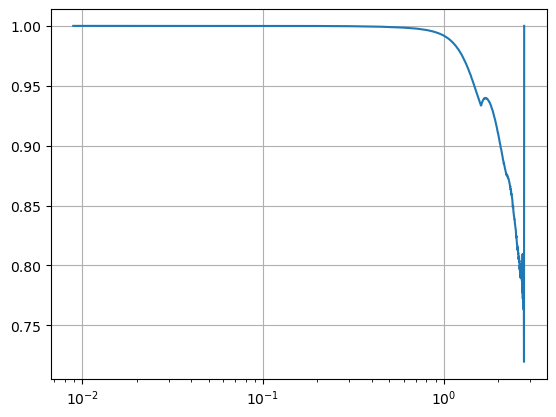

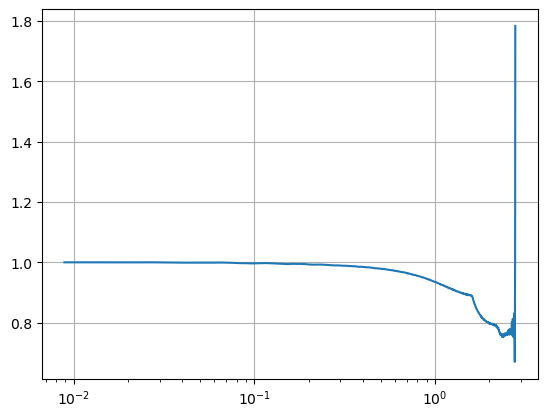

In [9]:
import numpy as np
import MAS_library as MASL

# density field parameters
grid    = 512    #the 3D field will have grid x grid x grid voxels
BoxSize = 1000.0 #Mpc/h ; size of box
MAS     = 'CIC'  #mass-assigment scheme
verbose = True   #print information on progress

dfp = np.load('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsnap_3_nsel_32768/0/pos_LH0_z05.npy')

delta_dj = np.zeros((grid,grid,grid), dtype=np.float32)
MASL.MA(dfp.astype(np.float32), delta_dj, BoxSize, MAS, verbose=verbose)

import numpy as np
import readgadget

# input files
snapshot = '/mnt/home/fvillaescusa/ceph/Quijote/Snapshots/latin_hypercube_HR/0/snapdir_003/snap_003'
ptype    = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

# read positions, velocities and IDs of the particles
posq = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h

delta_q = np.zeros((grid,grid,grid), dtype=np.float32)

# construct 3D density field
MASL.MA(posq, delta_q, BoxSize, MAS, verbose=verbose)


delta_dj /= np.mean(delta_dj, dtype=np.float32);  delta_dj -= 1.0

delta_q /= np.mean(delta_q, dtype=np.float32);  delta_q -= 1.0


import Pk_library as PKL

Pk = PKL.XPk([delta_dj,delta_q], BoxSize, 0, MAS=['CIC','CIC'], threads=1)








In [41]:
import pickle as pk
metaf_new = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_np_512_nsnap_3_nsel_32768/0/meta_dmo_fields_subvols_grid_8_LH_0.pkl', 'rb'))
metaf_new['cosmo']
# metaf_new.keys()



{'Omega_c': 0.10869,
 'Omega_b': 0.06681,
 'h': 0.7737,
 'n_s': 0.8849,
 'sigma8': 0.6641}

In [40]:
# import numpy as np
# np.linspace(12.7, 15.0, 96)
metaf_new['rand_sel']



array([255079,  17960, 100416, ...,  46704, 126990, 249570])

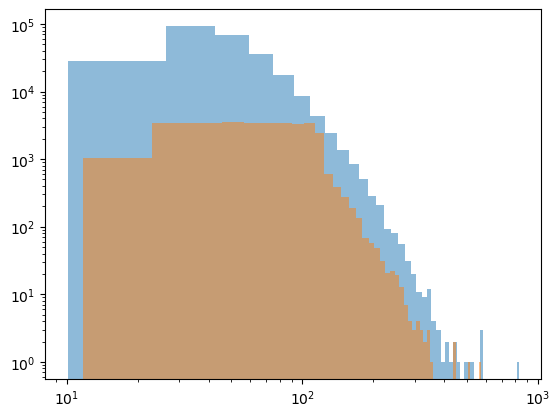

In [19]:
df_dm = np.load('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_np_512_nsnap_3_nsel_32768/0/dmo_fields_subvols_grid_8_LH_0.npy')
# df_dm.shape
metaf_new = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_np_512_nsnap_3_nsel_32768/0/meta_dmo_fields_subvols_grid_8_LH_0.pkl', 'rb'))
Npart_sum_all = metaf_new['Npart_sum_all']
Npart_sum_sel = metaf_new['Npart_sum_sel']

metaf_orig = pk.load(open('/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/0/meta_dmo_fields_subvols_grid_8_LH_0.pkl', 'rb'))
Npart_sum_all_orig = metaf_orig['Npart_sum_all']
Npart_sum_sel_orig = metaf_orig['Npart_sum_sel']

import matplotlib.pyplot as plt
plt.figure()
_ = plt.hist(Npart_sum_all, bins=50, alpha=0.5, label='All boxes')
_ = plt.hist(Npart_sum_sel, bins=50, alpha=0.5, label='Selected boxes')
plt.yscale('log')
plt.xscale('log')





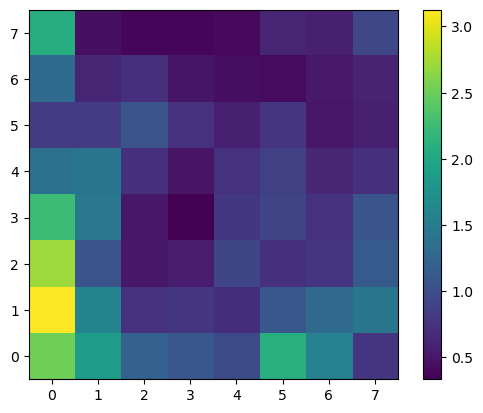

In [30]:
plt.figure()
plt.imshow(np.sum(df_dm[1, :, :, :, 10], axis=0), origin='lower')
plt.colorbar()




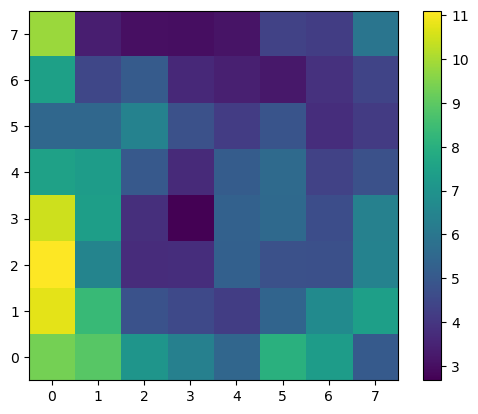

In [31]:
plt.figure()
plt.imshow(np.sum(df_dm[1, :, :, :, 11], axis=0), origin='lower')
plt.colorbar()




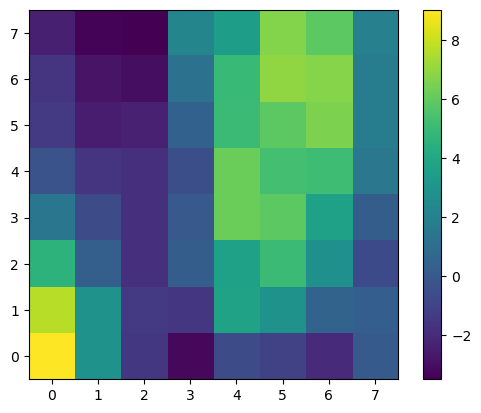

In [10]:
plt.figure()
plt.imshow(np.sum(df_dm[2, :, :, :, 9], axis=0), origin='lower')
plt.colorbar()




In [2]:
# ji = 0
from tqdm import tqdm
grid_sbox = 8
for ji in tqdm(numbers):
    process_LH_sim(ji, grid_sbox=grid_sbox)


  0%|          | 0/2000 [00:00<?, ?it/s]

File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/0/dmo_fields_subvols_grid_8_LH_0.npy


/tmp/ipykernel_407244/4202629439.py:128: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic
  0%|          | 2/2000 [04:05<68:08:51, 122.79s/it]

File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/2/dmo_fields_subvols_grid_8_LH_2.npy
File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/3/dmo_fields_subvols_grid_8_LH_3.npy


  0%|          | 7/2000 [16:20<89:05:26, 160.93s/it]

...

File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/10/dmo_fields_subvols_grid_8_LH_10.npy
File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/11/dmo_fields_subvols_grid_8_LH_11.npy
File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/12/dmo_fields_subvols_grid_8_LH_12.npy


  1%|          | 14/2000 [28:33<58:54:13, 106.77s/it]

File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/14/dmo_fields_subvols_grid_8_LH_14.npy
File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/15/dmo_fields_subvols_grid_8_LH_15.npy
File exists: /mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_32768/16/dmo_fields_subvols_grid_8_LH_16.npy


  1%|          | 17/2000 [28:49<56:01:54, 101.72s/it]


KeyboardInterrupt: 

In [ ]:
grid = 64
# nrand_sel_box = grid**3
nrand_sel_box = 32768
#snaps = ['05','07','1']
snaps = ['05']

root_in = '/mnt/ceph/users/spandey/discodj_runs/LH/%d/pm' % ji
root_out = '/mnt/ceph/users/spandey/discodj_runs/rhog_LH_nsel_%d/%d/' % (nrand_sel_box, ji)
os.makedirs(root_out, exist_ok=True)


savefname_dmo_fields = root_out + 'dmo_fields_subvols_grid_%d_LH_%d.npy'%(grid_sbox, ji)  
meta_fname = root_out + 'meta_dmo_fields_subvols_grid_%d_LH_%d.pkl'%(grid_sbox, ji)

for js, snapnum in enumerate(snaps):
    norm_delta = 10
    norm_vel = 100
    BoxSize = 1000.

    MAS_type = 'CIC'
    grid_tot = grid_sbox * grid

    import numpy as np
    np.random.seed(0)
    pos_m_truth = np.load(root_in + '/pos_LH%d_z05.npy' % ji)
    vel_m_truth = np.load(root_in + '/vel_LH%d_z05.npy' % ji)         

    rho_bar = len(pos_m_truth)/(BoxSize**3)
    vol_vox = (BoxSize/grid_tot)**3
    N_bar_vox = rho_bar * vol_vox

    Npart = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart, BoxSize, MAS_type, verbose=False)

    Npart /= N_bar_vox
    Npart /= norm_delta

    Npart_rs = mat_reshape(Npart, grid, grid_sbox)

    npad1 = grid_sbox
    Npart_pad1_rs, _ = get_padded_mat(Npart, int(npad1), grid_sbox, grid)

    npad2 = 2*grid_sbox
    Npart_pad2_rs, _ = get_padded_mat(Npart, int(npad2), grid_sbox, grid)

    vel_m_part = np.float32(np.zeros((grid_tot, grid_tot, grid_tot, 3)))

    Npart_cic = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
    MASL.MA(np.float32(pos_m_truth), Npart_cic, BoxSize, 'CIC', verbose=False)

    


    for jc in range(3):
        mom_jc = np.float32(np.zeros((grid_tot, grid_tot, grid_tot)))
        MASL.MA(np.float32(pos_m_truth), mom_jc, BoxSize, 'CIC', verbose=False, W=vel_m_truth[:,jc].astype(np.float32))
        vel_m_jc = mom_jc/Npart_cic
        vel_m_jc[~np.isfinite(vel_m_jc)] = 0.0
        vel_m_jc = fill_empty_voxels_with_local_average(vel_m_jc)            
        vel_m_part[..., jc] = vel_m_jc/norm_vel

    vel_m_part_rs = mat_reshape(vel_m_part, grid, grid_sbox)

    dmo_fields_all_snap = np.concatenate((Npart_rs[...,None], Npart_pad1_rs[...,None], Npart_pad2_rs[...,None], vel_m_part_rs), axis=-1) # (gird,gird,gird, 8, 8, 8, 6)

    if js == 0:
        dmo_fields_all = dmo_fields_all_snap
    else:
        dmo_fields_all = np.concatenate((dmo_fields_all, dmo_fields_all_snap), axis=-1)


dmo_fields_all_rs = dmo_fields_all.reshape((grid**3, *dmo_fields_all.shape[3:])) # (grid**3, 8, 8, 8, 6)

if nrand_sel_box < grid**3:
    import numpy as np
    np.random.seed(0)
    # import numpy as np
    # rng = np.random.default_rng(12345)
    dmo_fields_all_rs_z0 = dmo_fields_all_rs[:, ..., 0]
    Npart_sum = np.sum(dmo_fields_all_rs_z0, axis=(1, 2, 3))

    npart_min = np.percentile(Npart_sum, 2.0)
    npart_max = np.percentile(Npart_sum, 98.0)
    
    hist, bins_edges = np.histogram(np.clip(Npart_sum, npart_min, npart_max) , bins=16)
    bins_edges[0] = 0.0
    bins_edges[-1] = bins_edges[-1]*100
    nsel_per_jb = nrand_sel_box//len(hist)

    indsel_all = []
    for jbd in range(len(bins_edges)-1):
        b1 = bins_edges[jbd]
        b2 = bins_edges[jbd + 1]
        indsel = np.where((Npart_sum >= b1) & (Npart_sum < b2))[0]
        if len(indsel) < nsel_per_jb:
            ind_in_jb = indsel
        else:
            # ind_in_jb = rng.choice(indsel, nsel_per_jb, replace=False)
            ind_in_jb = np.random.choice(indsel, nsel_per_jb, replace=False)
        indsel_all.append(ind_in_jb)

    indsel_all = np.concatenate(indsel_all)

    if len(indsel_all) < nrand_sel_box:
        nmore_to_sel = nrand_sel_box - len(indsel_all)
        ind_to_sel_remaining = np.setdiff1d(np.arange(grid**3), indsel_all)
        # indsel_remaining = rng.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
        indsel_remaining = np.random.choice(ind_to_sel_remaining, nmore_to_sel, replace=False)
        indsel_all = np.concatenate((indsel_all, indsel_remaining))

    Npart_sum_sel = Npart_sum[indsel_all]
    # rand_sel = rng.permutation(indsel_all)
    rand_sel = np.random.permutation(indsel_all)
else:
    import numpy as np
    rand_sel = np.arange(grid**3)
    Npart_sum_sel = 0

np.save(savefname_dmo_fields, dmo_fields_all_rs.astype(np.float16)[rand_sel, ...])
# np.save(savefname_rand_indices, rand_sel)
saved = {
        'snapnums': snaps,
        'Npart_sum_all': Npart_sum,
        'Npart_sum_sel': Npart_sum_sel,
        'norm_delta': norm_delta,
        'norm_vel': norm_vel,
        'grid_sbox':grid_sbox,
        'grid':grid,
        'rand_sel': rand_sel,
        'MAS_type':MAS_type         
        }
pk.dump(saved, open(meta_fname, 'wb'))




/tmp/ipykernel_1208977/1188421667.py:57: RuntimeWarning: invalid value encountered in divide
  vel_m_jc = mom_jc/Npart_cic


NameError: name 'snapnums' is not defined

In [16]:
# dmo_fields_all_rs.shape
np.amin(dmo_fields_all_rs), np.amax(dmo_fields_all_rs)


(-17.18219757080078, 67.38256072998047)

In [9]:
import matplotlib.pyplot as plt


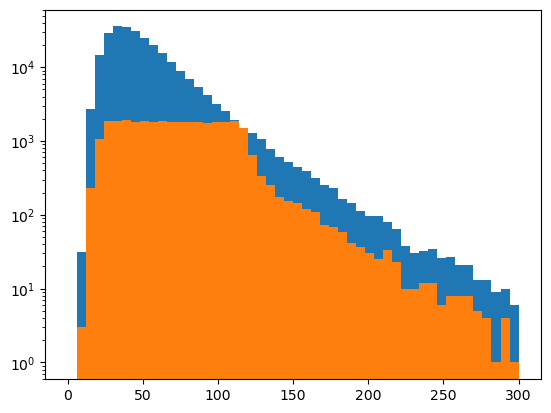

In [14]:
plt.figure()
_ = plt.hist(Npart_sum, bins=50, range=(0,300))
_ = plt.hist(Npart_sum_sel, bins=50, range=(0,300))
plt.yscale('log')





In [1]:
# Npart_sum
import numpy as np
np.linspace(1/128, 1/1.5, 20)




array([0.0078125 , 0.04248904, 0.07716557, 0.11184211, 0.14651864,
       0.18119518, 0.21587171, 0.25054825, 0.28522478, 0.31990132,
       0.35457785, 0.38925439, 0.42393092, 0.45860746, 0.49328399,
       0.52796053, 0.56263706, 0.5973136 , 0.63199013, 0.66666667])

In [3]:
import numpy as np
# from mpi4py import MPI
import sys, os

sim_id = 663
nfiles = 1
path = f'/mnt/ceph/users/spandey/discodj_runs/test_2gpc/LH/{sim_id}/ICs/'    
# savefname = path+'IC_delta640.npy'
savefname = path+'IC_delta1024.npy'

# check if the file already exists
# if os.path.exists(savefname):
    # continue

try:
    
    idx = []
    amp, phase = [], []
    print("\nConvert for path: ", path)

    for i in range(nfiles):
        # read a particular coordinate file
        f_in = path + 'Coordinates_ptype_1.%d'%i
        f = open(f_in, 'rb')
        Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
        Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
        Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
        coordinates = np.fromfile(f, dtype=np.int64, count=-1)
        kx = (coordinates//(Nmesh//2 + 1))//Nmesh
        ky = (coordinates//(Nmesh//2 + 1))%Nmesh
        kz = (coordinates%(Nmesh//2 + 1))%Nmesh
        kk = np.array([kx, ky, kz]).T
        idx.append(kk)

        f_in = path + 'Amplitudes_ptype_1.%d'%i
        f = open(f_in,'rb')
        Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
        Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
        Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
        aa = np.fromfile(f, dtype=np.float32, count=-1)
        amp.append(aa)
        f_in = path + 'Phases_ptype_1.%d'%i
        f = open(f_in,'rb')
        Nfiles = np.fromfile(f, dtype=np.int32, count=1)[0] #Number of coordinate subfiles  
        Nmesh  = np.fromfile(f, dtype=np.int32, count=1)[0] #Nmesh size
        Nx     = np.fromfile(f, dtype=np.int32, count=1)[0] #slab offset (not used)
        phase.append(np.fromfile(f, dtype=np.float32, count=-1))
except Exception as e:
    print("Error in reading files for sim_id: ", sim_id)
    pass

idx = np.concatenate(idx)
amp = np.concatenate(amp)
phase = np.concatenate(phase)

val = amp*np.exp(1j*phase)
cmesh = val.reshape(Nmesh, Nmesh, kz.max()+1)

bs=1000     #Mpc/h
mesh = np.fft.irfftn(cmesh, norm='ortho') * Nmesh**1.5
#np.save(path+'IC_delta128_cLH%d.npy'%sim_id, mesh.astype(np.float32))
np.save(savefname, mesh.astype(np.float32))


for i in range(nfiles):
    os.remove(path + 'Coordinates_ptype_1.%d'%i)
    os.remove(path + 'Amplitudes_ptype_1.%d'%i)
    os.remove(path + 'Phases_ptype_1.%d'%i)




Convert for path:  /mnt/ceph/users/spandey/discodj_runs/test_2gpc/LH/663/ICs/


In [4]:
for i in range(1,4):
    os.remove(path + 'Coordinates_ptype_1.%d'%i)
    os.remove(path + 'Amplitudes_ptype_1.%d'%i)
    os.remove(path + 'Phases_ptype_1.%d'%i)
